检验机器学习模型
流程：
1. FVCOM和SWAN计算结果，通过matlab程序“main_prepare_test_case.mlx”准备Environment_testcast.mat文件
- 文件包含风、潮、流、浪
- 变量中nan均替换成了0
2. 通过本程序加载mat数据，整理数据并用于预测
3. 加载**工作站**中训练好的模型，进行数据预测
4. 将预测结果与计算结果进行对比

# 加载数据

## 加载mat数据

In [1]:
# 加载mat数据
import scipy.io
import numpy as np
import os
import h5py # <-- 引入 h5py 库
from typing import Union, Dict, Any, Optional

def load_mat_variable(
    file_path: str, 
    variable_name: str
    ) -> Optional[np.ndarray]: # 简化返回类型提示，因为h5py通常返回ndarray
    """
    Load a specific variable from a MATLAB .mat file. 
    It attempts to use h5py for v7.3 files and scipy.io.loadmat for older files.

    Args:
        file_path (str): The full path to the .mat file.
        variable_name (str): The name of the variable to load.

    Returns:
        Optional[np.ndarray]: The data of the specified variable as a NumPy array, 
        or None if loading fails or the variable is not found.
    """
    # 1. 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"Error: File not found at '{file_path}'")
        return None

    # --- 尝试使用 h5py 读取 (针对 v7.3 文件) ---
    try:
        with h5py.File(file_path, 'r') as f:
            if variable_name in f:
                # h5py 返回一个 HDF5 数据集 (Dataset)，需要将其读入内存并转置 (MATLAB默认列优先)
                data = f[variable_name][()] 
                
                # h5py读取的数组可能需要转置，特别是对于二维及以上的数据，以匹配通常的Python/NumPy习惯。
                # 由于MATLAB是列优先，SciPy会处理；但h5py不会自动处理。
                # 经验上，对于非向量数据，通常需要转置。
                if data.ndim > 1:
                     data = data.T
                
                print(f"Successfully loaded '{variable_name}' (v7.3 HDF5) from '{file_path}'.")
                print(f"Data shape: {data.shape}")
                
                # 如果是 MATLAB 结构体，数据可能会以 HDF5 引用形式存在，处理会更复杂，
                # 但对于 'Wind' 这种常见的数值矩阵，上述代码通常足够。
                return data
            else:
                available_vars = list(f.keys())
                print(f"Error: Variable '{variable_name}' not found in the .mat file (v7.3 format).")
                print(f"Available variables: {available_vars}")
                return None
                
    except ImportError:
        print("Warning: h5py is not installed. Trying scipy.io.loadmat...")
        pass # 如果 h5py 未安装，则继续尝试 SciPy
        
    except Exception as e:
        # 如果 h5py 失败，可能是因为它不是 v7.3 文件，或者是文件损坏
        if "h5py" not in str(e): # 排除 h5py 自身的导入错误
             print(f"H5PY failed with error: {e}. Trying scipy.io.loadmat...")
        pass 
    
    # --- 尝试使用 scipy.io.loadmat 读取 (针对 v7.2 及更早版本) ---
    try:
        mat_contents = scipy.io.loadmat(file_path)
        
        if variable_name in mat_contents:
            data = mat_contents[variable_name]
            print(f"Successfully loaded '{variable_name}' (old format) from '{file_path}'.")
            
            if isinstance(data, np.ndarray):
                print(f"Data shape: {data.shape}")
                
            return data
        else:
            available_vars = [k for k in mat_contents.keys() if not k.startswith('__')]
            print(f"Error: Variable '{variable_name}' not found in the .mat file.")
            print(f"Available variables (excluding metadata): {available_vars}")
            return None

    except Exception as e:
        # 如果 SciPy 也失败了，说明文件可能损坏或路径有问题
        print(f"An error occurred while loading the file '{file_path}' using scipy: {e}")
        return None


# --- 示例调用 ---
file_path = r"../datas/Environment_202412.mat" 
variable_name = 'Wave' 
case_instance = 130 # 100 & 130 - 201623 Sarika; 100 & 110 - 201723 Khanun; 60 & 150 - 202203 Chaba; 100 & 130 - 202412 yagi

wind_data_mat = load_mat_variable(file_path, 'Wind')
# wind_data = wind_data_mat[case_instance - 1, :] if wind_data_mat is not None else None
# print(f"Wind data for case {case_instance}/{wind_data_mat.shape[0]}: {wind_data.shape}")

test_data_mat = load_mat_variable(file_path, variable_name)
# test_data = test_data_mat[case_instance - 1, :] if test_data_mat is not None else None
# print(f"{variable_name} data for case {case_instance}/{test_data_mat.shape[0]}: {test_data.shape}")

Successfully loaded 'Wind' (v7.3 HDF5) from '../datas/Environment_202412.mat'.
Data shape: (180, 4096)
Successfully loaded 'Wave' (v7.3 HDF5) from '../datas/Environment_202412.mat'.
Data shape: (180, 4096)


## 数据整理

In [2]:
import gc

# 研究区域坐标
x = np.linspace(105.3, 116.0, 64, dtype=float)
y = np.linspace(12.0, 23.0, 64, dtype=float)
X,Y = np.meshgrid(x, y)

# 将wind_data_mat进行转化
N, S = wind_data_mat.shape  # N时间步长，S空间点数(64*64=4096)
wind_2d = wind_data_mat.reshape(N, 64, 64).transpose(0, 2, 1)  # (N, 64, 64)

# 将wind_2d进行堆叠
wind_real = wind_2d['real'].astype(np.float32)  # (*, 64, 64)
wind_imag = wind_2d['imag'].astype(np.float32)  # 同上
wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (*, 2, 64, 64)
wind_combined = wind_combined[case_instance-1, :, :, :].reshape(1, 2, 64, 64)

print("Wind combined shape:", wind_combined.shape)


# 将test_data_mat进行转化
if variable_name.lower() == 'wave':
    data_2d = test_data_mat.reshape(N, 64, 64).transpose(0, 2, 1)
    true_2d = data_2d[case_instance - 1, :, :].astype(np.float32)  # (64, 64)
    print(f"{variable_name} shape:", true_2d.shape)

Wind combined shape: (1, 2, 64, 64)
Wave shape: (64, 64)


In [3]:
'''import gc


# 研究区域坐标
x = np.linspace(105.3, 116.0, 64, dtype=float)
y = np.linspace(12.0, 23.0, 64, dtype=float)
X,Y = np.meshgrid(x, y)

# 将 wind_2d 转换为与 X 相同的尺寸
wind_2d = wind_data.reshape(X.transpose().shape)  # 从 (3024,) 转换为 (56, 54)
wind_2d = wind_2d.transpose()
wind_real = wind_2d['real'].astype(np.float32)
wind_imag = wind_2d['imag'].astype(np.float32)  # 同上
wind_combined = np.stack([wind_real, wind_imag], axis=0)  # (2, 56, 54), 纯 float64
print("Wind combined shape:", wind_combined.shape)  # 应输出 (2, 56, 54)

test_2d = test_data.reshape(X.transpose().shape)  # 从 (3024,) 转换为 (54, 56)
test_2d = test_2d.transpose()
if variable_name == 'Current':
    current_real = test_2d['real'].astype(np.float32)
    current_imag = test_2d['imag'].astype(np.float32)
    true_2d = np.stack([current_real, current_imag], axis=0)
    print("Current combined shape:", true_2d.shape)
else:
    true_2d = test_2d.astype(np.float32)
    print(f"{variable_name} shape:", true_2d.shape)

# del wind_data, test_data, test_2d, wind_2d
# gc.collect()'''

'import gc\n\n\n# 研究区域坐标\nx = np.linspace(105.3, 116.0, 64, dtype=float)\ny = np.linspace(12.0, 23.0, 64, dtype=float)\nX,Y = np.meshgrid(x, y)\n\n# 将 wind_2d 转换为与 X 相同的尺寸\nwind_2d = wind_data.reshape(X.transpose().shape)  # 从 (3024,) 转换为 (56, 54)\nwind_2d = wind_2d.transpose()\nwind_real = wind_2d[\'real\'].astype(np.float32)\nwind_imag = wind_2d[\'imag\'].astype(np.float32)  # 同上\nwind_combined = np.stack([wind_real, wind_imag], axis=0)  # (2, 56, 54), 纯 float64\nprint("Wind combined shape:", wind_combined.shape)  # 应输出 (2, 56, 54)\n\ntest_2d = test_data.reshape(X.transpose().shape)  # 从 (3024,) 转换为 (54, 56)\ntest_2d = test_2d.transpose()\nif variable_name == \'Current\':\n    current_real = test_2d[\'real\'].astype(np.float32)\n    current_imag = test_2d[\'imag\'].astype(np.float32)\n    true_2d = np.stack([current_real, current_imag], axis=0)\n    print("Current combined shape:", true_2d.shape)\nelse:\n    true_2d = test_2d.astype(np.float32)\n    print(f"{variable_name} shape:", t

## 将数据归一化

In [4]:
import joblib
import numpy as np

scaler_wind = joblib.load('../datas/scaler_wind.joblib')
scaler_output = joblib.load(f'../datas/scaler_{variable_name.lower()}.joblib')
print("Scaler wind n_features_in_:", scaler_wind.n_features_in_)
print("Scaler output n_features_in_:", scaler_output.n_features_in_)

# 全局归一化：风速
wind_sample_reshaped = wind_combined.reshape(1, -1)  # (1, C*H*W)
wind_sample_norm_flat = scaler_wind.transform(wind_sample_reshaped)
wind_normalized = wind_sample_norm_flat.reshape(1, 2, 64, 64)
# 将wind_combined和true_2d进行归一化
'''wind_sample_reshaped = wind_combined.reshape(1, 2, 64, 64).transpose(0, 2, 3, 1).reshape(-1, 2)
wind_sample_norm_flat = scaler_wind.transform(wind_sample_reshaped)
wind_normalized = wind_sample_norm_flat.reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)'''

# 立即删除大数组
del wind_sample_reshaped, wind_sample_norm_flat
gc.collect()

# 输出变量归一化
if variable_name.lower() == 'current':
    # Current 也是 2 通道
    N, C, H, W = true_2d.shape
    out_reshaped = true_2d.transpose(0, 2, 3, 1).reshape(-1, C)

    out_normalized_flat = scaler_output.transform(out_reshaped)
    output_normalized = out_normalized_flat.reshape(N, H, W, C).transpose(0, 3, 1, 2)

    del out_reshaped, out_normalized_flat
    gc.collect()    
else:
    # Surge / Wave 是 1 通道 (1, 64, 64) -> (1*64*64, 1)
    output_flat = true_2d.reshape(1, -1)
    # output_flat = true_2d.reshape(-1, 1)

    out_normalized_flat = scaler_output.transform(output_flat)
    output_normalized = out_normalized_flat.reshape(true_2d.shape)

    # 立即释放内存
    del output_flat, out_normalized_flat
    gc.collect()

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")
print(f"Output normalized min/max: {np.nanmin(output_normalized):.2f} / {np.nanmax(output_normalized):.2f}")

Scaler wind n_features_in_: 8192
Scaler output n_features_in_: 4096
Normalized wind NaN: False
Normalized output NaN: False
Wind normalized min/max: -1.00 / 0.91
Output normalized min/max: 0.00 / 0.98


d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


绘制风速和变量的空间地图

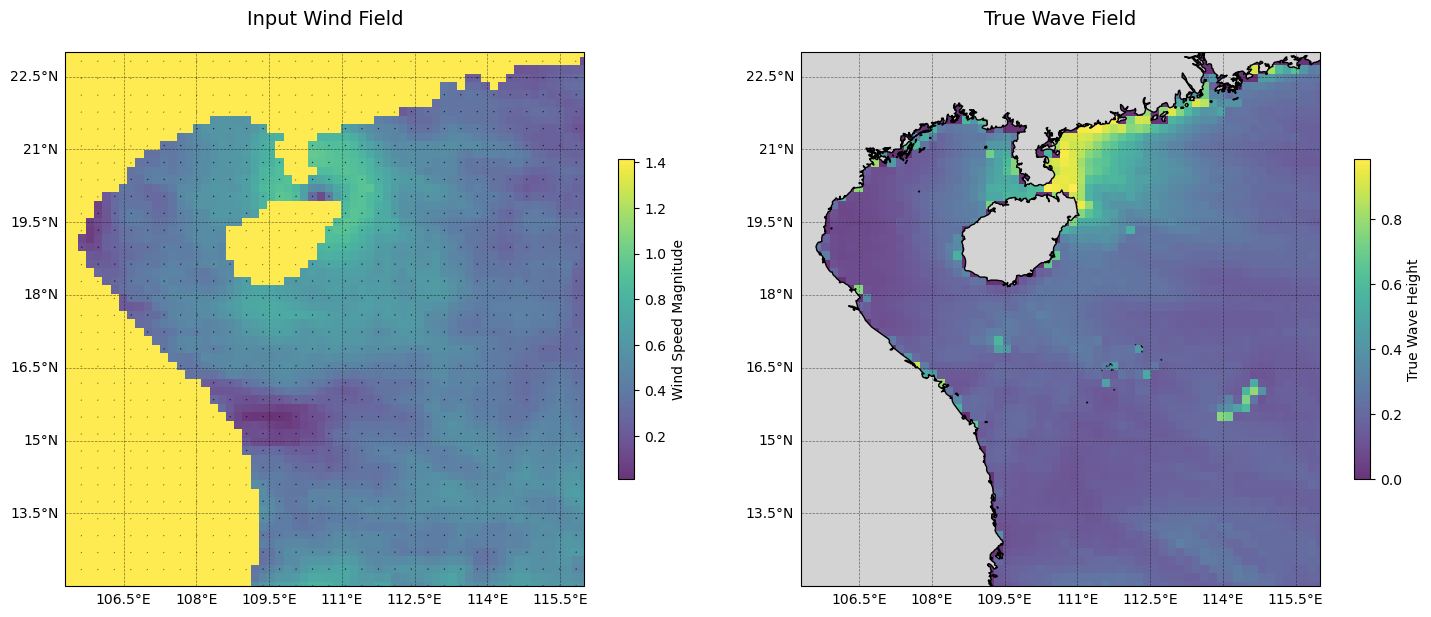

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [105.3, 116.0, 12.0, 23.0]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_inversed = scaler_wind.inverse_transform(wind_normalized.reshape(1, -1)).reshape(1, 2, 64, 64)
wind_field_np = np.sqrt(wind_normalized[0, 0, :, :]**2 + wind_normalized[0, 1, :, :]**2)
'''wind_field_np = np.sqrt(wind_combined[0,:]**2 + wind_combined[1,:]**2)'''

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)
# set the colorbar range
# im1.set_clim(0,1)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_normalized[0, 0, ::skip, ::skip]
Vq = wind_normalized[0, 1, ::skip, ::skip]
'''Uq = wind_combined[0, ::skip, ::skip]
Vq = wind_combined[1, ::skip, ::skip]'''
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Add land and features
# ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
if variable_name.lower() == 'current':
    true_2d_np_abs = np.sqrt(true_2d[0]**2 + true_2d[1]**2)  # 计算流速幅值
    im2 = ax2.pcolormesh(X, Y, true_2d_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label='True Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = true_2d[0, ::skip, ::skip]
    Vq = true_2d[1, ::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
else:
    im2 = ax2.pcolormesh(X, Y, output_normalized, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label=f'True {variable_name.capitalize()} Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title(f'True {variable_name.capitalize()} Field', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# 加载模型

In [6]:
import torch
# 关键步骤：导入类定义
from f_model_defination import UNetBoosting, XGBoostUNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 实例化结构 (参数必须与训练时一致)

if variable_name.lower() == 'wave':
    '''boosting_model = UNetBoosting(num_models=5, in_channels=2, out_channels=1, learning_rate=1e-3, 
        shrinkage=0.6, features=[32, 64, 128, 256, 512],device=device, env_type=variable_name.lower()
    ).to(device)'''
                                                                    
    # 创建 XGBoostUNet 实例
    boosting_model = XGBoostUNet(
        num_models=4,          # 弱学习器的数量
        learning_rate=7e-4,   # 学习率(默认1e-3)
        shrinkage=0.6,         # 子模型收缩率
        subsample=0.8,         # 样本采样比例
        reg_lambda=1e-4,       # L2 正则化
        features=[16, 32, 64, 128],
        env_type='wave',       # 根据环境类型自动选择梯度计算方式
        device=device
    )




# 2. 加载权重
print(f"Loading model weights for {variable_name}...")
'''boosting_model.load_state_dict(
    torch.load(f'../datas/unet_boosting_{variable_name.lower()}_model_v5.7.pth', map_location=device)
)'''
boosting_model.load_state_dict(torch.load(f'../datas/optim_xgboosting_unet_{variable_name.lower()}_model_v6.1.pth', map_location=device))



d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'GradScaler' from 'torch.amp' (d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\torch\amp\__init__.py)

# 预报

In [ ]:
import torch

# 准备输入张量
wind_tensor = torch.from_numpy(wind_normalized).float().to(device)
# wind_tensor = wind_tensor.unsqueeze(0)  # 添加批次维度，变为 (1, 2, 56, 54)

# 模型推理
boosting_model.eval()
with torch.no_grad():
    env_pred_normalized = boosting_model(wind_tensor)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (56, 54)
print("Predicted normalized shape:", env_pred_normalized_np.shape)


# 反归一化
if variable_name.lower() == 'current':
    # 对于 current，有两个通道
    env_pred_flat = env_pred_normalized_np.reshape(1, -1)  # (1, 2*56*54)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(2, 64, 64)  # (2, 64, 64)
else:
    env_pred_flat = env_pred_normalized_np.reshape(1, -1)  # (1, 56*54)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)

if variable_name.lower() == 'current':
    true_speed = np.sqrt(true_2d[0]**2 + true_2d[1]**2)  # 计算流速幅值
    true_index = np.unravel_index(np.argmax(true_speed), true_speed.shape)
    print("True max value: %.2f, max value index: %d" %(np.max(true_speed), np.argmax(true_speed)))
    print("Maximum u, v for true: %.2f, %.2f" %(true_2d[0, true_index[0], true_index[1]], true_2d[1, true_index[0], true_index[1]]))
    pred_speed = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    pred_index = np.unravel_index(np.argmax(pred_speed), pred_speed.shape)
    print("Predicted max value: %.2f, max value index: %d" %(np.max(pred_speed), np.argmax(pred_speed)))
    print("Maximum u, v for predicted: %.2f, %.2f" %(env_pred_np[0, pred_index[0], pred_index[1]], env_pred_np[1, pred_index[0], pred_index[1]]))
else:
    print("True max value:", np.max(true_2d))
    print("True max value (normalized):", np.max(output_normalized))
    print("Predicted max value:", np.max(env_pred_np))
    print("Predicted max value (normalized):", np.max(env_pred_normalized_np))

In [ ]:
print("scaler_output.min_.shape:", scaler_output.min_.shape)
print("scaler_output.scale_.shape:", scaler_output.scale_.shape)
print("scaler_output.n_features_in_:", scaler_output.n_features_in_)

## 结果可视化

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [105.3, 116.0, 12.0, 23.0]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_field_np = np.sqrt(wind_combined[0,0,:]**2 + wind_combined[0,1,:]**2)

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_combined[0, 0, ::skip, ::skip]
Vq = wind_combined[0, 1, ::skip, ::skip]
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Add land and features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
if variable_name.lower() == 'current':
    pred_2d_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im2 = ax2.pcolormesh(X, Y, pred_2d_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label='Predicted Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0, ::skip, ::skip]
    Vq = env_pred_np[1, ::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
else:
    im2 = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label=f'Predicted {variable_name.capitalize()} Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title(f'Predicted {variable_name.capitalize()} Field', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 定义格式器（如果之前代码中已定义，可忽略）
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# 对比图：预测 vs 真实（子图）
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 6))

# 真实场
ax1.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
# pcolormesh for wave height
if variable_name.lower() == 'current':
    true_sample_abs = np.sqrt(true_2d[0]**2 + true_2d[1]**2)  # 计算流速幅值
    im_true = ax1.pcolormesh(X, Y, true_sample_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Current Speed', shrink=0.6)
    # ax1.set_title('True Current Field', fontsize=14, pad=20)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = true_2d[0][::skip, ::skip]
    Vq = true_2d[1][::skip, ::skip]
    ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax1.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_true = ax1.pcolormesh(X, Y, true_2d, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax1, orientation='vertical', label=f'True {variable_name.capitalize()} Height', shrink=0.6)
    # ax1.set_title(f'True {variable_name.capitalize()} Field', fontsize=14, pad=20)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
# im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

# 预测场
ax2.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
# pcolormesh for wave height
if variable_name.lower() == 'current':
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im_pred = ax2.pcolormesh(X, Y, env_pred_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    # ax2.set_title('Predicted Current Field', fontsize=14, pad=20)
    fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0][::skip, ::skip]
    Vq = env_pred_np[1][::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax2.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    # ax2.set_title(f'Predicted {variable_name.capitalize()} Field', fontsize=14, pad=20)
    fig.colorbar(im_pred, ax=ax2, orientation='vertical', label=f'{variable_name.capitalize()} Height', shrink=0.6)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 添加colorbar并设置范围，与真实场一致（在 im_pred 上调用 set_clim）
im_pred.set_clim(vmin=im_true.get_clim()[0], vmax=im_true.get_clim()[1])  # 修复：移到 im_pred 上
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl2.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
plt.show()

# 打印对比统计
mse = np.mean((env_pred_np - true_2d)**2)
mae = np.mean(np.abs(env_pred_np - true_2d))
correlation = np.corrcoef(env_pred_np.flatten(), true_2d.flatten())[0, 1]
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {correlation:.4f}")

# 高值区域 MAE
high_region = true_2d > np.percentile(true_2d, 90)
print(f"高值区 MAE: {np.mean(np.abs(env_pred_np[high_region] - true_2d[high_region])):.4f}")

In [ ]:
# 对比图：预测 vs 真实（子图）
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(6, 6))

# 真实场
ax.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
# pcolormesh for wave height
if variable_name.lower() == 'current':
    true_sample_abs = np.sqrt(true_2d[0]**2 + true_2d[1]**2)  # 计算流速幅值
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im_true = ax.pcolormesh(X, Y, env_pred_np_abs - true_sample_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax, orientation='vertical', label='Predicted Current Speed Variance', shrink=0.6)
else:
    im_true = ax.pcolormesh(X, Y, env_pred_np - true_2d, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax, orientation='vertical', label=f'Predicted {variable_name.capitalize()} Height Variance', shrink=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
plt.show()